In [1]:
import os
import sys

sys.path.append(os.path.abspath("../src"))


from utils import load_dataset, dataset_info
from eda import perform_eda
from preprocessing import preprocess_data
from feature_selection import select_features
from classification import train_classification
from metrics import classification_metrics


from validation import compare_cross_validation
from timing import compare_training_prediction_time


from visualization import (
    plot_accuracy_vs_k,
    plot_classifier_comparison,
    plot_training_time,
    plot_prediction_time,
    plot_cv_scores,
    plot_grid_search_heatmap,
    plot_random_search_distribution
)


from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.neighbors import KNeighborsClassifier


import pandas as pd
import numpy as np
import time

In [2]:
df = load_dataset("spambase.csv")

In [3]:
dataset_info(df)

DATASET INFORMATION

Shape : (4601, 58)

Columns
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B

In [4]:
print(df.columns.tolist())

['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 'char_freq_%21', 'char_freq_%24', 'char_freq_%

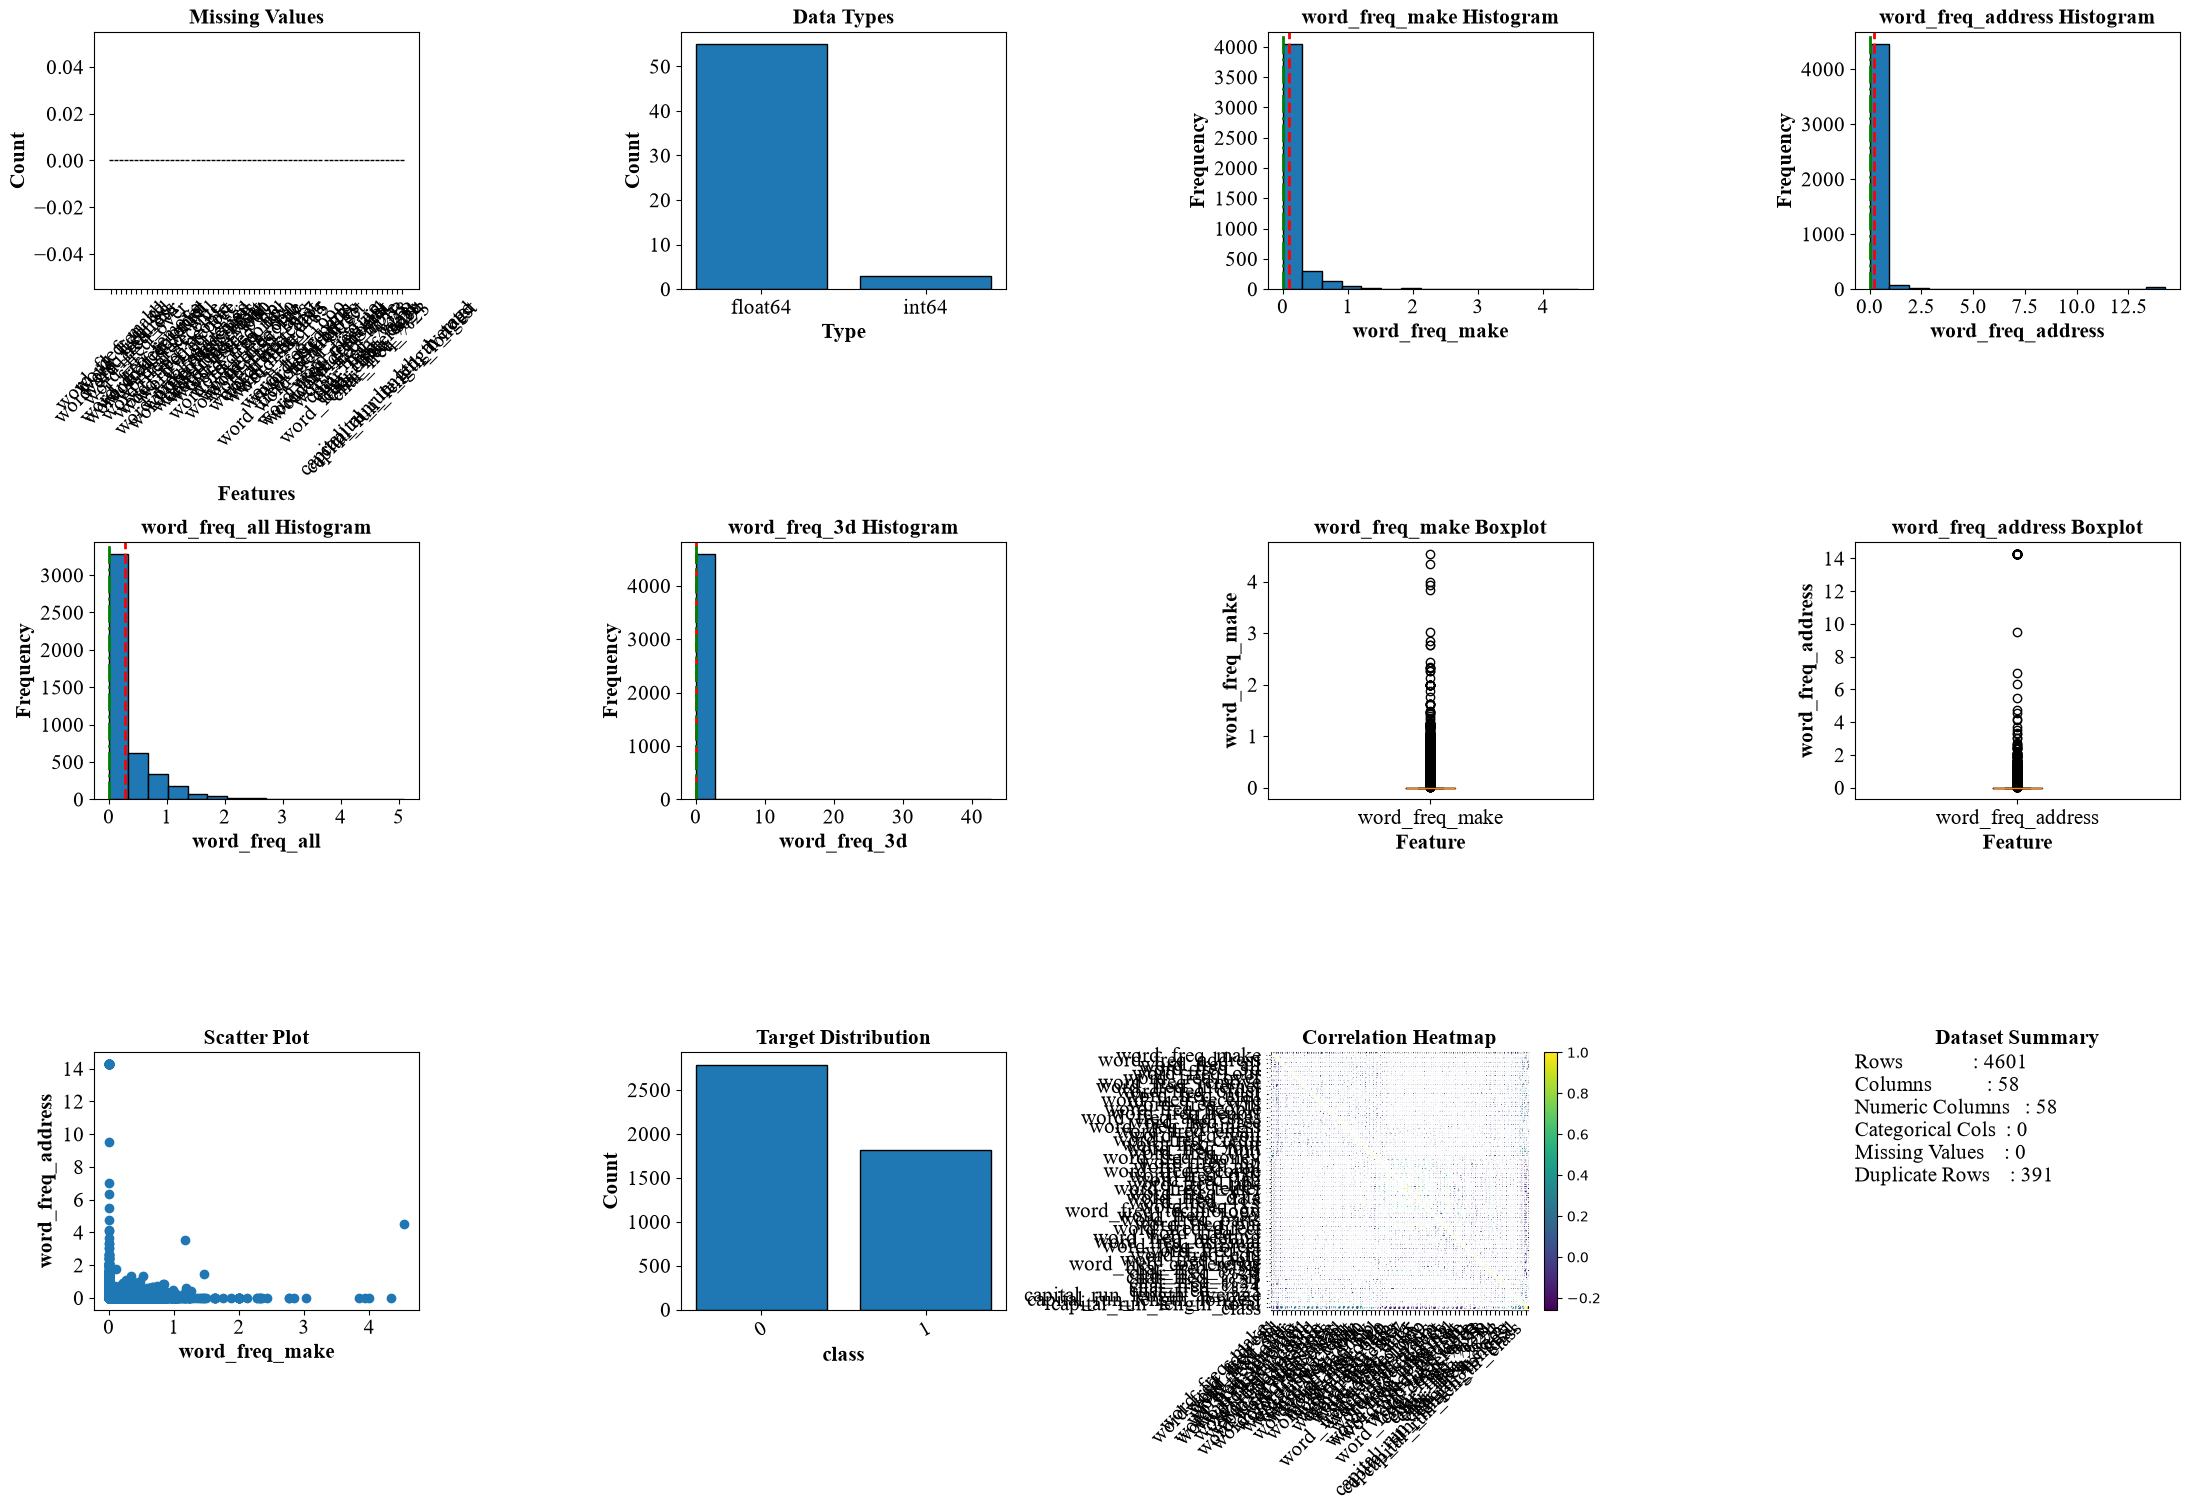

In [5]:
summary = perform_eda(
    df=df,
    target_column="class",
    save=True,
    filename="spambase_eda"
)

In [6]:
'''Preprocessing (Scaled)

Used for

GaussianNB
KNN'''
X_train, X_test, y_train, y_test, scaler, encoders = preprocess_data(
    df=df,
    target_column="class",
    drop_cols=None,
    encode=True,
    scale=True,
    stratify=True,
    test_size=0.2,
    random_state=42
)

In [7]:
'''Preprocessing (Without Scaling)

Used for

MultinomialNB
BernoulliNB'''

X_train_nb, X_test_nb, y_train_nb, y_test_nb, _, _ = preprocess_data(
    df=df,
    target_column="class",
    drop_cols=None,
    encode=True,
    scale=False,
    stratify=True,
    test_size=0.2,
    random_state=42
)

In [8]:
X_train, X_test, selector = select_features(
    X_train,
    X_test,
    y_train,
    method="anova",
    k="all"
)

X_train_nb, X_test_nb, selector = select_features(
    X_train_nb,
    X_test_nb,
    y_train_nb,
    method="anova",
    k="all"
)


========== Classification Metrics ==========

Accuracy : 0.8290
Precision: 0.8616
Recall   : 0.8290
F1 Score : 0.8306

Confusion Matrix

[[378 128]
 [ 16 320]]

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.75      0.84       506
           1       0.71      0.95      0.82       336

    accuracy                           0.83       842
   macro avg       0.84      0.85      0.83       842
weighted avg       0.86      0.83      0.83       842

ROC AUC : 0.9471


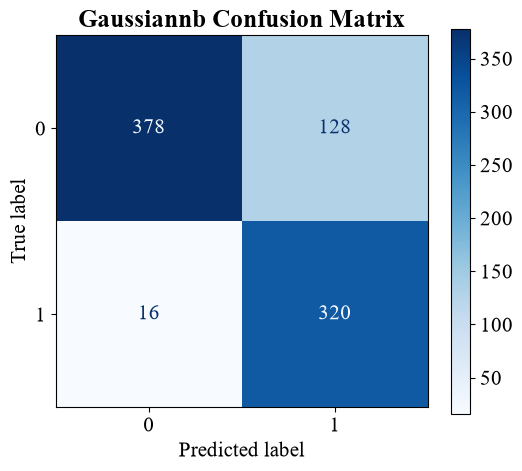

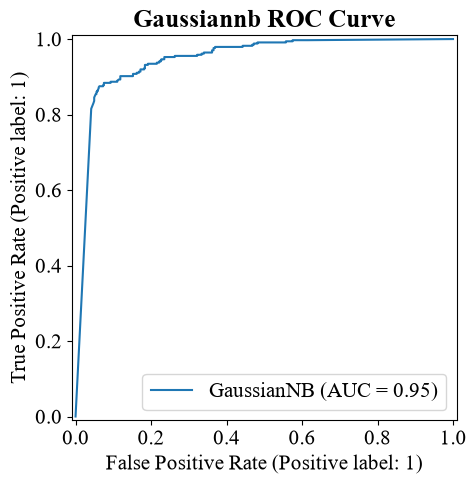

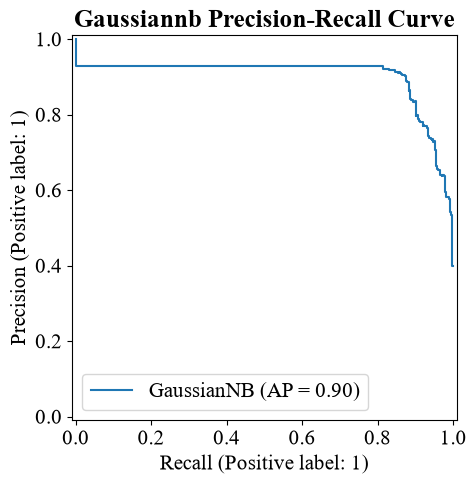

In [9]:
gaussian_nb = train_classification(
    X_train,
    y_train,
    algorithm="gaussian_nb"
)


gaussian_results = classification_metrics(
    gaussian_nb,
    X_test,
    y_test,
    model_name="GaussianNB"
)


========== Classification Metrics ==========

Accuracy : 0.7886
Precision: 0.7869
Recall   : 0.7886
F1 Score : 0.7864

Confusion Matrix

[[434  72]
 [106 230]]

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       506
           1       0.76      0.68      0.72       336

    accuracy                           0.79       842
   macro avg       0.78      0.77      0.78       842
weighted avg       0.79      0.79      0.79       842

ROC AUC : 0.8342


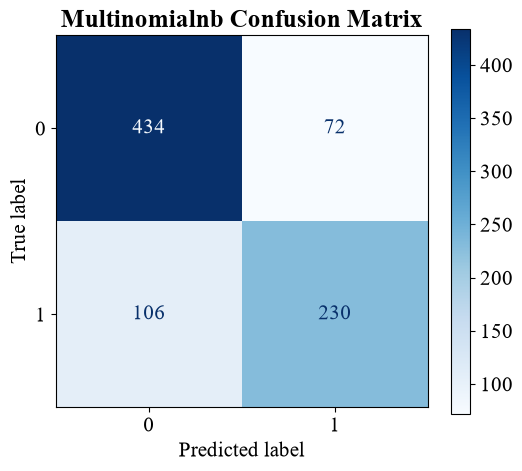

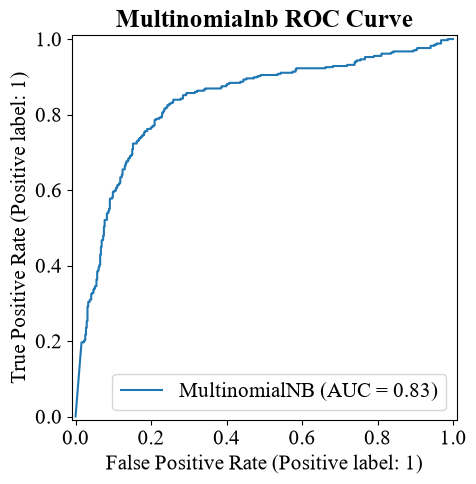

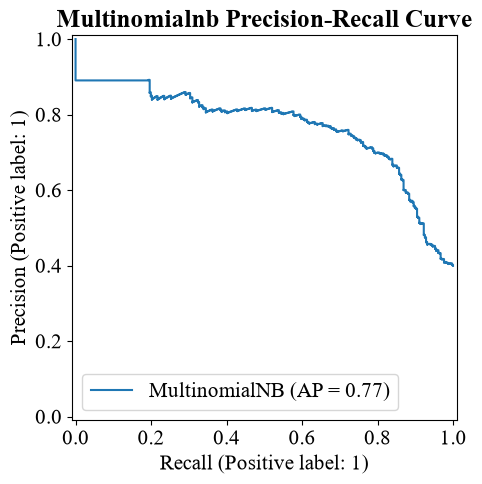

In [10]:
multinomial_nb = train_classification(
    X_train_nb,
    y_train_nb,
    algorithm="multinomial_nb"
)


multinomial_results = classification_metrics(
    multinomial_nb,
    X_test_nb,
    y_test_nb,
    model_name="MultinomialNB"
)


========== Classification Metrics ==========

Accuracy : 0.8943
Precision: 0.8940
Recall   : 0.8943
F1 Score : 0.8940

Confusion Matrix

[[466  40]
 [ 49 287]]

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       506
           1       0.88      0.85      0.87       336

    accuracy                           0.89       842
   macro avg       0.89      0.89      0.89       842
weighted avg       0.89      0.89      0.89       842

ROC AUC : 0.9609


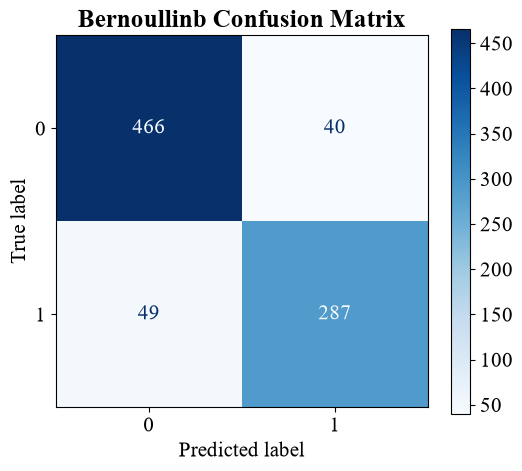

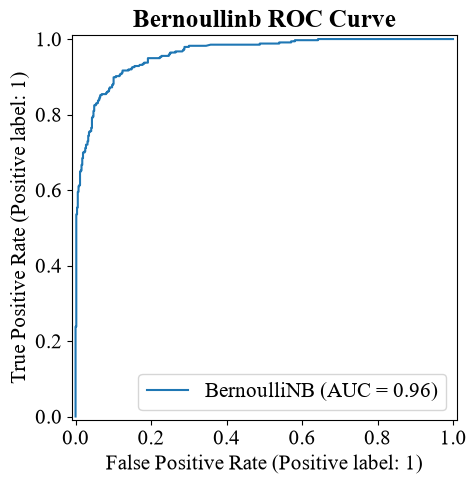

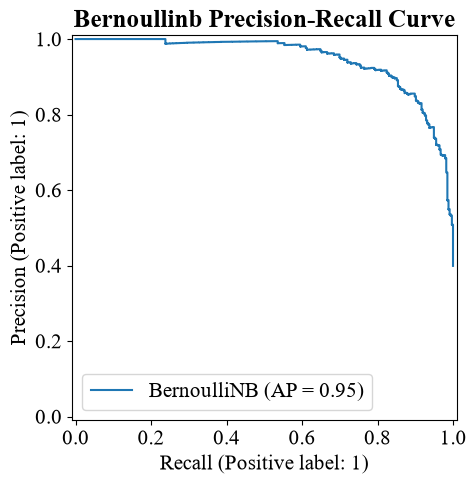

In [11]:
bernoulli_nb = train_classification(
    X_train_nb,
    y_train_nb,
    algorithm="bernoulli_nb"
)


bernoulli_results = classification_metrics(
    bernoulli_nb,
    X_test_nb,
    y_test_nb,
    model_name="BernoulliNB"
)


========== Classification Metrics ==========

Accuracy : 0.9109
Precision: 0.9111
Recall   : 0.9109
F1 Score : 0.9104

Confusion Matrix

[[479  27]
 [ 48 288]]

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       506
           1       0.91      0.86      0.88       336

    accuracy                           0.91       842
   macro avg       0.91      0.90      0.91       842
weighted avg       0.91      0.91      0.91       842

ROC AUC : 0.9548


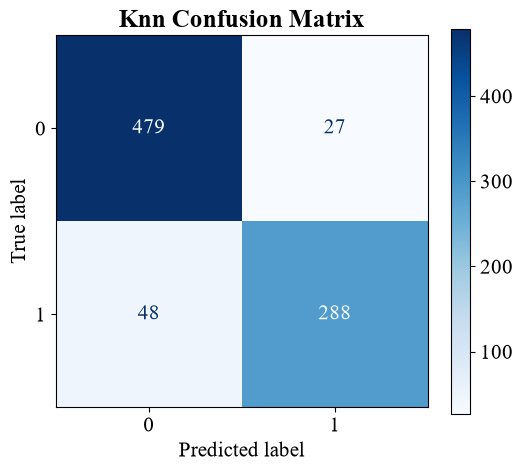

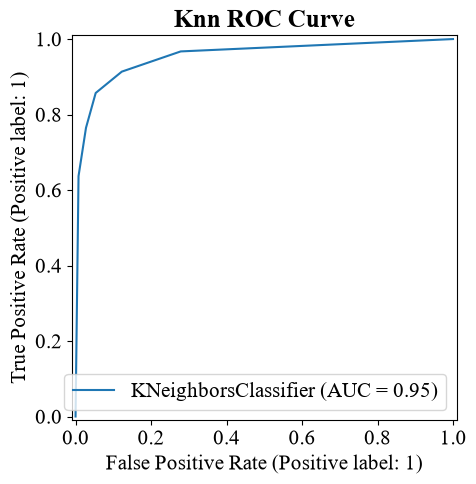

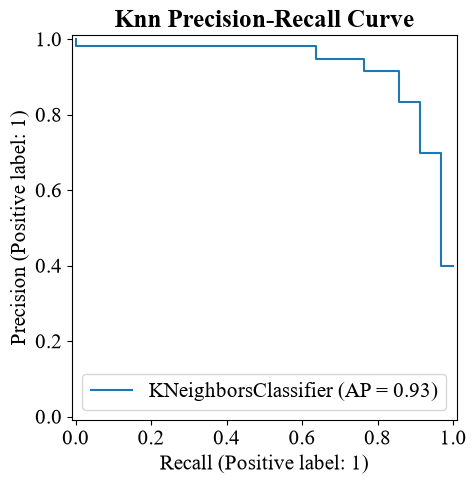

In [12]:
knn = train_classification(
    X_train,
    y_train,
    algorithm="knn",
    k=5
)


knn_results = classification_metrics(
    knn,
    X_test,
    y_test,
    model_name="KNN"
)

In [13]:
k_values = [1,3,5,7,9,11]


knn_k_results = []


for k in k_values:

    model = train_classification(
        X_train,
        y_train,
        algorithm="knn",
        k=k
    )


    predictions = model.predict(
        X_test
    )


    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score
    )


    knn_k_results.append({

        "k":k,

        "Accuracy":
        accuracy_score(
            y_test,
            predictions
        ),

        "Precision":
        precision_score(
            y_test,
            predictions
        ),

        "Recall":
        recall_score(
            y_test,
            predictions
        ),

        "F1":
        f1_score(
            y_test,
            predictions
        )

    })


knn_k_table = pd.DataFrame(
    knn_k_results
)


knn_k_table

,k,Accuracy,Precision,Recall,F1
0,1,0.904988,0.883234,0.877976,0.880597
1,3,0.902613,0.894410,0.857143,0.875380
2,5,0.910926,0.914286,0.857143,0.884793
3,7,0.908551,0.916399,0.848214,0.880989
4,9,0.902613,0.917763,0.830357,0.871875
5,11,0.901425,0.912052,0.833333,0.870918


In [14]:
parameters = {

    "n_neighbors":[1,3,5,7,9,11],

    "weights":["uniform","distance"],

    "metric":["euclidean","manhattan"],

    "algorithm":["auto","kd_tree","ball_tree"]

}


grid = GridSearchCV(

    KNeighborsClassifier(),

    parameters,

    cv=5,

    scoring="accuracy"

)


grid.fit(
    X_train,
    y_train
)


print("Best Parameters")
print(grid.best_params_)


print()

print("Best Accuracy")
print(grid.best_score_)


grid_results = pd.DataFrame(
    grid.cv_results_
)


grid_results[
[
"param_n_neighbors",
"param_weights",
"param_metric",
"param_algorithm",
"mean_test_score"
]
]

Best Parameters
{'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

Best Accuracy
0.9112239364023969


,param_n_neighbors,param_weights,param_metric,param_algorithm,mean_test_score
0,1,uniform,euclidean,auto,0.884507
1,1,distance,euclidean,auto,0.884507
2,3,uniform,euclidean,auto,0.895189
3,3,distance,euclidean,auto,0.897270
4,5,uniform,euclidean,auto,0.895488
...,...,...,...,...,...
67,7,distance,manhattan,ball_tree,0.907361
68,9,uniform,manhattan,ball_tree,0.899937
69,9,distance,manhattan,ball_tree,0.910924
70,11,uniform,manhattan,ball_tree,0.900535


In [15]:
random = RandomizedSearchCV(

    KNeighborsClassifier(),

    parameters,

    cv=5,

    n_iter=10,

    random_state=42

)


random.fit(
    X_train,
    y_train
)


print("Best Parameters")
print(random.best_params_)


print()

print("Best Accuracy")
print(random.best_score_)


random_results = pd.DataFrame(
    random.cv_results_
)


random_results[
[
"param_n_neighbors",
"param_weights",
"param_metric",
"param_algorithm",
"mean_test_score"
]
]

Best Parameters
{'weights': 'uniform', 'n_neighbors': 3, 'metric': 'manhattan', 'algorithm': 'ball_tree'}

Best Accuracy
0.9014219514023306


,param_n_neighbors,param_weights,param_metric,param_algorithm,mean_test_score
0,5,uniform,euclidean,auto,0.895488
1,3,uniform,manhattan,ball_tree,0.901422
2,7,uniform,manhattan,auto,0.898452
3,1,uniform,euclidean,auto,0.884507
4,5,uniform,euclidean,kd_tree,0.895488
5,3,uniform,euclidean,ball_tree,0.895189
6,11,uniform,euclidean,auto,0.889254
7,11,uniform,euclidean,kd_tree,0.889254
8,1,uniform,manhattan,auto,0.888661
9,7,uniform,euclidean,ball_tree,0.893112


In [16]:
tree_results=[]


for algo in ["kd_tree","ball_tree"]:


    start=time.time()


    model=train_classification(

        X_train,
        y_train,

        algorithm="knn",

        algorithm_type=algo

    )


    train_time=time.time()-start


    start=time.time()


    predictions=model.predict(
        X_test
    )


    predict_time=time.time()-start


    accuracy=model.score(
        X_test,
        y_test
    )


    tree_results.append({

        "Algorithm":algo,

        "Accuracy":accuracy,

        "Training Time":train_time,

        "Prediction Time":predict_time

    })


tree_table=pd.DataFrame(
    tree_results
)


tree_table

,Algorithm,Accuracy,Training Time,Prediction Time
0,kd_tree,0.910926,0.053821,0.419750
1,ball_tree,0.910926,0.036320,0.497597


In [17]:
cv_models={

    "Gaussian NB":gaussian_nb,

    "Best KNN":knn

}


cv_table = compare_cross_validation(

    cv_models,

    X_train,

    y_train,

    folds=5

)


cv_table

MODEL CROSS VALIDATION COMPARISON
         Gaussian NB  Best KNN
Fold 1      0.813056  0.890208
Fold 2      0.838279  0.896142
Fold 3      0.836795  0.902077
Fold 4      0.824666  0.912333
Fold 5      0.800892  0.900446
Average     0.822738  0.900241


,Gaussian NB,Best KNN
Fold 1,0.813056,0.890208
Fold 2,0.838279,0.896142
Fold 3,0.836795,0.902077
Fold 4,0.824666,0.912333
Fold 5,0.800892,0.900446
Average,0.822738,0.900241


In [18]:
models_time = {

    "GaussianNB": (
        gaussian_nb,
        X_train,
        X_test,
        y_train
    ),

    "MultinomialNB": (
        multinomial_nb,
        X_train_nb,
        X_test_nb,
        y_train_nb
    ),

    "BernoulliNB": (
        bernoulli_nb,
        X_train_nb,
        X_test_nb,
        y_train_nb
    ),

    "KNN": (
        knn,
        X_train,
        X_test,
        y_train
    )

}


time_results = []


for name, values in models_time.items():

    model, Xtr, Xte, ytr = values


    start = time.perf_counter()

    model.fit(
        Xtr,
        ytr
    )

    train_time = time.perf_counter() - start


    start = time.perf_counter()

    model.predict(
        Xte
    )

    prediction_time = time.perf_counter() - start


    time_results.append({

        "Algorithm": name,

        "Training Time(s)": train_time,

        "Prediction Time(s)": prediction_time

    })


time_table = pd.DataFrame(
    time_results
)


time_table

,Algorithm,Training Time(s),Prediction Time(s)
0,GaussianNB,0.013390,0.001641
1,MultinomialNB,0.005443,0.000786
2,BernoulliNB,0.011579,0.002394
3,KNN,0.003634,0.020594
